In [14]:
from pathlib import Path
import tifffile
from astropy.io import fits

src_root = Path('./NCU Spotlight/raw_data')
dst_root = src_root / 'fits_outputs'
dst_root.mkdir(parents=True, exist_ok=True)

all_tif_files = [
    p for p in src_root.rglob('*')
    if p.is_file()
    and p.suffix.lower() in ('.tif', '.tiff')
    and 'fits_outputs' not in p.relative_to(src_root).parts
    and not any(part.startswith('.') for part in p.relative_to(src_root).parts)
]

converted = 0
failed = 0

for tif_path in sorted(all_tif_files):
    out_path = dst_root / tif_path.relative_to(src_root).parent / f'{tif_path.stem}.fits'
    out_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        image_data = tifffile.imread(str(tif_path))
        fits.PrimaryHDU(image_data).writeto(str(out_path), overwrite=True)
        print(f'CONVERTED: {tif_path.relative_to(src_root)} -> {out_path.relative_to(src_root)}')
        converted += 1
    except Exception as exc:
        print(f'FAILED: {tif_path.relative_to(src_root)} ({exc})')
        failed += 1

print(f'Summary: {converted} converted, {failed} failed')

CONVERTED: 20260525_PAN1.tif -> fits_outputs/20260525_PAN1.fits
CONVERTED: 20260525_PAN2.tif -> fits_outputs/20260525_PAN2.fits
CONVERTED: 20260602_PAN1.tif -> fits_outputs/20260602_PAN1.fits
CONVERTED: 20260602_PAN2.tif -> fits_outputs/20260602_PAN2.fits
CONVERTED: 20260603_PAN1.tif -> fits_outputs/20260603_PAN1.fits
CONVERTED: 20260603_PAN2.tif -> fits_outputs/20260603_PAN2.fits
CONVERTED: 20260622_PAN1.tif -> fits_outputs/20260622_PAN1.fits
CONVERTED: 20260622_PAN2.tif -> fits_outputs/20260622_PAN2.fits
CONVERTED: 20260623_PAN2.tif -> fits_outputs/20260623_PAN2.fits
CONVERTED: 20260702_PAN1.tif -> fits_outputs/20260702_PAN1.fits
CONVERTED: 20260702_PAN2.tif -> fits_outputs/20260702_PAN2.fits
CONVERTED: 20260707_PAN1.tif -> fits_outputs/20260707_PAN1.fits
CONVERTED: 20260707_PAN2.tif -> fits_outputs/20260707_PAN2.fits
CONVERTED: 20260709_PAN1.tif -> fits_outputs/20260709_PAN1.fits
CONVERTED: 20260709_PAN2.tif -> fits_outputs/20260709_PAN2.fits
CONVERTED: 20260716_PAN1.tif -> fits_out

In [43]:
from pathlib import Path
import re
import numpy as np
import sep
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.ndimage import shift as ndi_shift
from scipy.spatial import cKDTree
from skimage.registration import phase_cross_correlation
from astropy.io import fits

workspace_root = Path('/Users/chyan/Desktop/NCU Spotlight')

# Paths
fits_candidates = [
    workspace_root / 'fits_outputs',
    workspace_root / 'NCU Spotlight' / 'fits_outputs',
    Path.cwd() / 'fits_outputs',
    Path.cwd() / 'NCU Spotlight' / 'fits_outputs',
]
stack_candidates = [
    workspace_root / 'fits_stacked',
    workspace_root / 'NCU Spotlight' / 'fits_stacked',
    Path.cwd() / 'fits_stacked',
    Path.cwd() / 'NCU Spotlight' / 'fits_stacked',
]
fits_root = next((p for p in fits_candidates if p.exists()), fits_candidates[0])
stack_root = next((p for p in stack_candidates if p.exists()), stack_candidates[0])
stack_root.mkdir(parents=True, exist_ok=True)
pdf_path = stack_root / 'pan_pair_triptych.pdf'

# Parameters
fallback_shift = (-0.5, -0.5)
n_bright = 30
match_radius = 1.0
min_matches_ok = 2
max_rms_ok = 1.0


def center_crop(arr, ny, nx):
    y0 = max(0, (arr.shape[0] - ny) // 2)
    x0 = max(0, (arr.shape[1] - nx) // 2)
    return arr[y0:y0 + ny, x0:x0 + nx]


def detect_sources(image, thresh=4.0, minarea=5):
    finite = np.isfinite(image)
    if np.count_nonzero(finite) < 100:
        return np.empty((0, 2)), np.empty((0,))

    fill = float(np.nanmedian(image[finite]))
    img = np.where(finite, image, fill).astype(np.float32)
    bkg = sep.Background(img)
    obj = sep.extract(img - bkg, thresh=thresh, err=bkg.globalrms, minarea=minarea)

    if len(obj) == 0:
        return np.empty((0, 2)), np.empty((0,))

    coords = np.vstack([obj['y'], obj['x']]).T.astype(np.float64)
    flux = np.asarray(obj['flux'], dtype=np.float64)
    return coords, flux


def match_stats(coords1, coords2, shift_yx, radius=1.0):
    if len(coords1) == 0 or len(coords2) == 0:
        return 0, np.inf

    tree = cKDTree(coords2)
    query = np.column_stack([coords1[:, 0] - shift_yx[0], coords1[:, 1] - shift_yx[1]])
    dist, nn = tree.query(query, distance_upper_bound=radius)
    good = np.isfinite(dist) & (dist < radius)
    if np.count_nonzero(good) == 0:
        return 0, np.inf

    # Keep one-to-one matches by nearest distance.
    dist_good = dist[good]
    nn_good = nn[good]
    order = np.argsort(dist_good)
    used = set()
    keep = []
    for k in order:
        j = int(nn_good[k])
        if j in used:
            continue
        used.add(j)
        keep.append(float(dist_good[k]))

    if not keep:
        return 0, np.inf
    keep = np.asarray(keep, dtype=np.float64)
    return len(keep), float(np.sqrt(np.mean(keep**2)))


def stack_with_shift(data1, data2, shift_yx):
    data2_aligned = ndi_shift(data2, shift=shift_yx, order=3, mode='constant', cval=np.nan)
    valid2 = ndi_shift(np.ones_like(data2, dtype=np.float32), shift=shift_yx, order=0, mode='constant', cval=0.0) > 0.5
    return np.where(valid2, 0.5 * (data1 + data2_aligned), np.nan)


def sharpness_score(stacked, ref_coords):
    finite = np.isfinite(stacked)
    if np.count_nonzero(finite) < 50:
        return -np.inf

    if len(ref_coords) == 0:
        med = np.nanmedian(stacked[finite])
        std = np.nanstd(stacked[finite]) + 1e-6
        return float((np.nanmax(stacked[finite]) - med) / std)

    vals = []
    for y, x in ref_coords:
        yi = int(round(y))
        xi = int(round(x))
        if yi < 3 or xi < 3 or yi >= stacked.shape[0] - 3 or xi >= stacked.shape[1] - 3:
            continue
        patch = stacked[yi - 2:yi + 3, xi - 2:xi + 3]
        ok = np.isfinite(patch)
        if np.count_nonzero(ok) < 20:
            continue
        p = patch[ok]
        b = np.median(p)
        peak = np.max(p) - b
        flux = np.sum(np.clip(p - b, 0.0, None)) + 1e-6
        vals.append(peak / flux)

    return float(np.median(vals)) if vals else -np.inf


def estimate_shift_catalog(coords1, flux1, coords2, flux2):
    if len(coords1) == 0 or len(coords2) == 0:
        return fallback_shift

    c1 = coords1[np.argsort(flux1)[-n_bright:]]
    c2 = coords2[np.argsort(flux2)[-n_bright:]]

    dy = c1[:, None, 0] - c2[None, :, 0]
    dx = c1[:, None, 1] - c2[None, :, 1]
    deltas = np.column_stack([dy.ravel(), dx.ravel()])

    # Use 2D histogram mode as robust global shift estimate.
    q = np.round(deltas * 4.0) / 4.0
    uniq, cnt = np.unique(q, axis=0, return_counts=True)
    return (float(uniq[np.argmax(cnt), 0]), float(uniq[np.argmax(cnt), 1]))


def estimate_shift_phase(data1, data2):
    finite1 = np.isfinite(data1)
    finite2 = np.isfinite(data2)
    if np.count_nonzero(finite1) < 50 or np.count_nonzero(finite2) < 50:
        return fallback_shift

    fill1 = float(np.nanmedian(data1[finite1]))
    fill2 = float(np.nanmedian(data2[finite2]))
    img1 = np.where(finite1, data1, fill1).astype(np.float32)
    img2 = np.where(finite2, data2, fill2).astype(np.float32)
    img1 -= np.median(img1)
    img2 -= np.median(img2)

    s, _, _ = phase_cross_correlation(img1, img2, upsample_factor=20)
    return (float(s[0]), float(s[1]))


def refine_shift(data1, data2, coords1, coords2, flux1, base_shift):
    if len(coords1) > 0:
        ref_coords = coords1[np.argsort(flux1)[-12:]]
    else:
        ref_coords = np.empty((0, 2))

    dy0, dx0 = base_shift
    dy_grid = np.arange(dy0 - 0.6, dy0 + 0.6 + 1e-9, 0.1)
    dx_grid = np.arange(dx0 - 0.6, dx0 + 0.6 + 1e-9, 0.1)

    best = None
    for dy in dy_grid:
        for dx in dx_grid:
            s = (float(dy), float(dx))
            n_match, rms = match_stats(coords1, coords2, s, radius=match_radius)
            st = stack_with_shift(data1, data2, s)
            sharp = sharpness_score(st, ref_coords)
            score = sharp + 0.01 * n_match - 0.02 * (rms if np.isfinite(rms) else 10.0)
            if (best is None) or (score > best['score']):
                best = {'shift': s, 'n_match': n_match, 'rms': rms, 'stacked': st, 'score': score}

    return best


def robust_limits(arr):
    finite = np.isfinite(arr)
    if np.count_nonzero(finite) < 10:
        return 0.0, 1.0
    vmin, vmax = np.nanpercentile(arr[finite], [5, 99.5])
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmax <= vmin):
        return float(np.nanmin(arr[finite])), float(np.nanmax(arr[finite]))
    return float(vmin), float(vmax)


pan1_files = sorted(fits_root.rglob('*PAN1.fits')) if fits_root.exists() else []
combined = 0
missing = 0
failed = 0
cropped = 0
fallback_used = 0

with PdfPages(pdf_path) as pdf:
    for pan1_path in pan1_files:
        pan2_name = re.sub(r'PAN1\.fits$', 'PAN2.fits', pan1_path.name, flags=re.IGNORECASE)
        pan2_path = pan1_path.with_name(pan2_name)

        if not pan2_path.exists():
            print(f'MISSING PAIR: {pan1_path.relative_to(fits_root)} (no PAN2)')
            missing += 1
            continue

        try:
            data1 = fits.getdata(pan1_path).astype(np.float32)
            data2 = fits.getdata(pan2_path).astype(np.float32)
            if data1.ndim < 2 or data2.ndim < 2:
                print(f'INVALID DIMENSION: {pan1_path.name} or {pan2_path.name}')
                failed += 1
                continue

            ny = min(data1.shape[0], data2.shape[0])
            nx = min(data1.shape[1], data2.shape[1])
            if data1.shape[:2] != (ny, nx) or data2.shape[:2] != (ny, nx):
                print(f'CROP TO OVERLAP: {pan1_path.name} {data1.shape[:2]} & {pan2_path.name} {data2.shape[:2]} -> {(ny, nx)}')
                cropped += 1

            data1_crop = center_crop(data1, ny, nx)
            data2_crop = center_crop(data2, ny, nx)

            coords1, flux1 = detect_sources(data1_crop)
            coords2, flux2 = detect_sources(data2_crop)

            # Three candidates: catalog / phase / fallback, each with local refinement.
            cands = {
                'catalog': estimate_shift_catalog(coords1, flux1, coords2, flux2),
                'phase': estimate_shift_phase(data1_crop, data2_crop),
                'fallback': fallback_shift,
            }

            evals = {name: refine_shift(data1_crop, data2_crop, coords1, coords2, flux1, s) for name, s in cands.items()}
            method = max(evals, key=lambda k: evals[k]['score'])
            best = evals[method]

            # Require minimum matching quality unless fallback is best by score.
            if method != 'fallback':
                ok = best['n_match'] >= min_matches_ok and np.isfinite(best['rms']) and best['rms'] <= max_rms_ok
                if not ok:
                    method = 'fallback'
                    best = evals['fallback']
                    fallback_used += 1
            else:
                fallback_used += 1

            shift_yx = best['shift']
            n_match = best['n_match']
            rms = best['rms']
            stacked = best['stacked']
            score_gain = best['score'] - evals['fallback']['score']

            out_name = re.sub(r'PAN1\.fits$', 'PAN_stack.fits', pan1_path.name, flags=re.IGNORECASE)
            out_path = stack_root / pan1_path.relative_to(fits_root).parent / out_name
            out_path.parent.mkdir(parents=True, exist_ok=True)

            hdr = fits.getheader(pan1_path)
            hdr['HISTORY'] = 'PAN2 aligned by simplified hybrid SEP+phase estimator'
            hdr['SHIFT_Y'] = (shift_yx[0], 'Shift applied to PAN2 along Y (pixel)')
            hdr['SHIFT_X'] = (shift_yx[1], 'Shift applied to PAN2 along X (pixel)')
            hdr['SHFMETH'] = (method, 'Selected shift method')
            hdr['NMATCH'] = (n_match, 'One-to-one matched stars')
            hdr['RMSSHF'] = (float(rms) if np.isfinite(rms) else -1.0, 'Residual RMS, -1 if invalid')
            hdr['SCGAIN'] = (float(score_gain), 'Score gain over fallback')
            hdr['STACKED'] = ('PAN1+PAN2', 'Two-frame stacked product')

            fits.PrimaryHDU(stacked.astype(np.float32), header=hdr).writeto(out_path, overwrite=True)

            # PDF triptych: PAN1, PAN2, STACK
            p1_vmin, p1_vmax = robust_limits(data1_crop)
            p2_vmin, p2_vmax = robust_limits(data2_crop)
            st_vmin, st_vmax = robust_limits(stacked)

            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(data1_crop, origin='lower', cmap='gray', vmin=p1_vmin, vmax=p1_vmax)
            axes[0].set_title('PAN1')
            axes[1].imshow(data2_crop, origin='lower', cmap='gray', vmin=p2_vmin, vmax=p2_vmax)
            axes[1].set_title('PAN2')
            axes[2].imshow(stacked, origin='lower', cmap='gray', vmin=st_vmin, vmax=st_vmax)
            axes[2].set_title('STACK')
            for ax in axes:
                ax.set_xlabel('X')
                ax.set_ylabel('Y')

            fig.suptitle(f"{pan1_path.stem} | shift=(dy={shift_yx[0]:.3f}, dx={shift_yx[1]:.3f}), method={method}, matched={n_match}, rms={rms if np.isfinite(rms) else float('nan'):.3f}")
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

            print(f'STACKED: {pan1_path.relative_to(fits_root)} + {pan2_path.relative_to(fits_root)} | shift={shift_yx}, method={method}, matched={n_match}, rms={rms:.3f} -> {out_path.relative_to(stack_root.parent)}')
            combined += 1

        except Exception as exc:
            print(f'FAILED: {pan1_path.name} ({exc})')
            failed += 1

print(f'PDF: {pdf_path}')
print(f'Summary: {combined} stacked, {missing} missing pairs, {failed} failed, {cropped} overlap-cropped, {fallback_used} fallback-used')

CROP TO OVERLAP: 20260525_PAN1.fits (67, 70) & 20260525_PAN2.fits (68, 71) -> (67, 70)
STACKED: 20260525_PAN1.fits + 20260525_PAN2.fits | shift=(-1.0, 0.10000000000000098), method=fallback, matched=0, rms=inf -> fits_stacked/20260525_PAN_stack.fits
CROP TO OVERLAP: 20260602_PAN1.fits (63, 62) & 20260602_PAN2.fits (63, 56) -> (63, 56)
STACKED: 20260602_PAN1.fits + 20260602_PAN2.fits | shift=(5.000000190734861, 1.9500000476837158), method=phase, matched=3, rms=0.514 -> fits_stacked/20260602_PAN_stack.fits
CROP TO OVERLAP: 20260603_PAN1.fits (70, 62) & 20260603_PAN2.fits (69, 58) -> (69, 58)
STACKED: 20260603_PAN1.fits + 20260603_PAN2.fits | shift=(-1.149999976158142, 0.800000023841858), method=phase, matched=3, rms=0.311 -> fits_stacked/20260603_PAN_stack.fits
CROP TO OVERLAP: 20260622_PAN1.fits (59, 52) & 20260622_PAN2.fits (49, 40) -> (49, 40)
STACKED: 20260622_PAN1.fits + 20260622_PAN2.fits | shift=(2.7, -1.9999999999999991), method=catalog, matched=2, rms=0.594 -> fits_stacked/202606

#### Using only correlation

CROP TO OVERLAP: 20260525_PAN1.fits (67, 70) & 20260525_PAN2.fits (68, 71)
STACKED: 20260525_PAN1.fits + 20260525_PAN2.fits | shift=(-1.7500000238418574, -3.499999999999999), corr=0.7888, psf_n=3, psf_med=1.83 -> fits_stacked/20260525_PAN_stack.fits
CROP TO OVERLAP: 20260602_PAN1.fits (63, 62) & 20260602_PAN2.fits (63, 56)
STACKED: 20260602_PAN1.fits + 20260602_PAN2.fits | shift=(4.8000001907348615, 2.350000047683716), corr=0.9371, psf_n=1, psf_med=1.84 -> fits_stacked/20260602_PAN_stack.fits
CROP TO OVERLAP: 20260603_PAN1.fits (70, 62) & 20260603_PAN2.fits (69, 58)
STACKED: 20260603_PAN1.fits + 20260603_PAN2.fits | shift=(-0.7499999761581417, 0.6000000238418579), corr=0.9693, psf_n=1, psf_med=2.06 -> fits_stacked/20260603_PAN_stack.fits
CROP TO OVERLAP: 20260622_PAN1.fits (59, 52) & 20260622_PAN2.fits (49, 40)
STACKED: 20260622_PAN1.fits + 20260622_PAN2.fits | shift=(3.0499999523162846, -2.600000095367431), corr=0.9664, psf_n=1, psf_med=1.78 -> fits_stacked/20260622_PAN_stack.fits
CRO

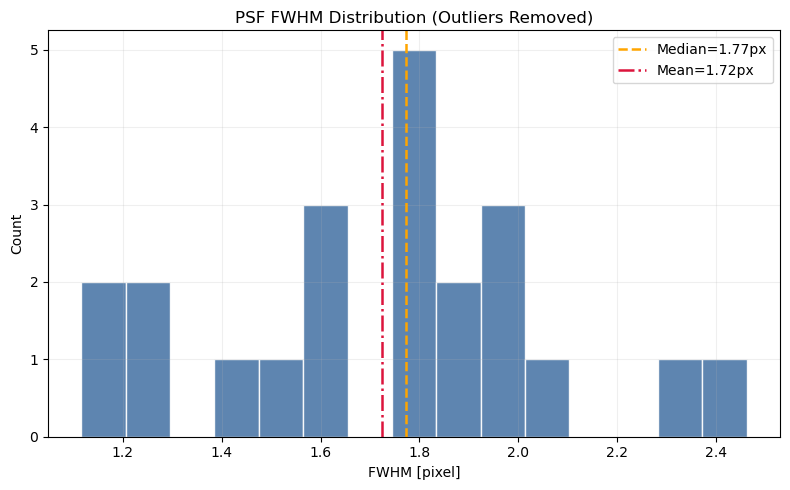

PSF Distribution (cleaned): N=22, removed=3, median=1.77px, mean=1.72px
IQR bounds: [0.77, 2.68] px
PDF: /Users/chyan/Desktop/NCU Spotlight/fits_stacked/pan_pair_triptych.pdf
Summary: 9 stacked, 0 missing pairs, 0 failed, 9 overlap-cropped, 0 fallback-used


In [52]:
from pathlib import Path
import re
import numpy as np
import sep
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.ndimage import shift as ndi_shift
from scipy.optimize import curve_fit
from skimage.registration import phase_cross_correlation
from astropy.io import fits

workspace_root = Path('/Users/chyan/Desktop/NCU Spotlight')

# Correlation-only shift parameters.
fallback_shift = (-0.5, -0.5)
upsample_factor = 20
fine_half_range = 0.6
fine_step = 0.1

# PSF measurement/label parameters.
sep_thresh_sigma = 3.5
sep_minarea = 5
bright_flux_quantile = 0.7  # only label brighter stars
max_labels = 20

# PSF outlier-cleaning parameters for final distribution.
outlier_iqr_k = 1.5
min_points_for_iqr = 8


def first_existing(candidates):
    return next((p for p in candidates if p.exists()), candidates[0])


def get_roots():
    fits_root = first_existing([
        workspace_root / 'fits_outputs',
        workspace_root / 'NCU Spotlight' / 'fits_outputs',
        Path.cwd() / 'fits_outputs',
        Path.cwd() / 'NCU Spotlight' / 'fits_outputs',
    ])
    stack_root = first_existing([
        workspace_root / 'fits_stacked',
        workspace_root / 'NCU Spotlight' / 'fits_stacked',
        Path.cwd() / 'fits_stacked',
        Path.cwd() / 'NCU Spotlight' / 'fits_stacked',
    ])
    stack_root.mkdir(parents=True, exist_ok=True)
    return fits_root, stack_root


def center_crop(arr, ny, nx):
    y0 = max(0, (arr.shape[0] - ny) // 2)
    x0 = max(0, (arr.shape[1] - nx) // 2)
    return arr[y0:y0 + ny, x0:x0 + nx]


def crop_pair_to_common_center(data1, data2):
    ny = min(data1.shape[0], data2.shape[0])
    nx = min(data1.shape[1], data2.shape[1])
    return center_crop(data1, ny, nx), center_crop(data2, ny, nx)


def preprocess_for_corr(image):
    finite = np.isfinite(image)
    if np.count_nonzero(finite) < 50:
        return None

    fill = float(np.nanmedian(image[finite]))
    img = np.where(finite, image, fill).astype(np.float32)
    img -= np.median(img)
    std = np.std(img)
    if std > 0:
        img /= std
    return img


def corr_score(ref_img, mov_img, shift_yx):
    moved = ndi_shift(mov_img, shift=shift_yx, order=3, mode='constant', cval=np.nan)
    valid = np.isfinite(ref_img) & np.isfinite(moved)
    if np.count_nonzero(valid) < 100:
        return -np.inf

    a = ref_img[valid].astype(np.float64)
    b = moved[valid].astype(np.float64)
    a -= np.mean(a)
    b -= np.mean(b)
    denom = np.linalg.norm(a) * np.linalg.norm(b) + 1e-12
    return float(np.dot(a, b) / denom)


def estimate_shift_correlation(data1, data2):
    ref_img = preprocess_for_corr(data1)
    mov_img = preprocess_for_corr(data2)
    if ref_img is None or mov_img is None:
        return fallback_shift, -np.inf, np.nan

    coarse, phase_err, _ = phase_cross_correlation(ref_img, mov_img, upsample_factor=upsample_factor)
    dy0, dx0 = float(coarse[0]), float(coarse[1])

    dy_grid = np.arange(dy0 - fine_half_range, dy0 + fine_half_range + 1e-9, fine_step)
    dx_grid = np.arange(dx0 - fine_half_range, dx0 + fine_half_range + 1e-9, fine_step)

    best_shift = (dy0, dx0)
    best_corr = -np.inf
    for dy in dy_grid:
        for dx in dx_grid:
            s = (float(dy), float(dx))
            c = corr_score(ref_img, mov_img, s)
            if c > best_corr:
                best_corr = c
                best_shift = s

    return best_shift, best_corr, float(phase_err)


def stack_pair(data1, data2, shift_yx):
    moved = ndi_shift(data2, shift=shift_yx, order=3, mode='constant', cval=np.nan)
    valid = ndi_shift(np.ones_like(data2, dtype=np.float32), shift=shift_yx, order=0, mode='constant', cval=0.0) > 0.5
    return np.where(valid, 0.5 * (data1 + moved), np.nan)


def image_limits(arr):
    finite = np.isfinite(arr)
    if np.count_nonzero(finite) < 10:
        return 0.0, 1.0
    vmin, vmax = np.nanpercentile(arr[finite], [5, 99.5])
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmax <= vmin):
        return float(np.nanmin(arr[finite])), float(np.nanmax(arr[finite]))
    return float(vmin), float(vmax)


def gaussian2d_model(xy, amp, x0, y0, sx, sy, theta, offset):
    x, y = xy
    ct, st = np.cos(theta), np.sin(theta)
    a = (ct**2) / (2.0 * sx**2) + (st**2) / (2.0 * sy**2)
    b = -np.sin(2.0 * theta) / (4.0 * sx**2) + np.sin(2.0 * theta) / (4.0 * sy**2)
    c = (st**2) / (2.0 * sx**2) + (ct**2) / (2.0 * sy**2)
    z = amp * np.exp(-(a * (x - x0) ** 2 + 2.0 * b * (x - x0) * (y - y0) + c * (y - y0) ** 2)) + offset
    return z.ravel()


def fit_psf_on_patch(image, x, y, half_size=6):
    ny, nx = image.shape
    xi, yi = int(round(x)), int(round(y))
    x1, x2 = max(0, xi - half_size), min(nx, xi + half_size + 1)
    y1, y2 = max(0, yi - half_size), min(ny, yi + half_size + 1)

    patch = image[y1:y2, x1:x2]
    if patch.size < 25:
        return None

    valid = np.isfinite(patch)
    if np.count_nonzero(valid) < 25:
        return None

    z = patch.astype(np.float64)
    yy, xx = np.indices(z.shape, dtype=np.float64)

    z_med = np.nanmedian(z)
    z_peak = np.nanmax(z)
    amp0 = max(z_peak - z_med, 1e-3)
    p0 = [amp0, float(x - x1), float(y - y1), 1.5, 1.5, 0.0, z_med]
    lower = [0.0, 0.0, 0.0, 0.3, 0.3, -np.pi / 2.0, -np.inf]
    upper = [np.inf, z.shape[1] - 1.0, z.shape[0] - 1.0, 8.0, 8.0, np.pi / 2.0, np.inf]

    try:
        popt, _ = curve_fit(
            gaussian2d_model,
            (xx[valid], yy[valid]),
            z[valid].ravel(),
            p0=p0,
            bounds=(lower, upper),
            maxfev=10000,
        )
    except Exception:
        return None

    _, x0, y0, sx, sy, _, _ = popt
    sx = float(abs(sx))
    sy = float(abs(sy))
    sigma = np.sqrt(0.5 * (sx**2 + sy**2))
    fwhm = 2.354820045 * sigma

    return {'x': x1 + float(x0), 'y': y1 + float(y0), 'fwhm': float(fwhm)}


def measure_psf_for_bright_stars(stacked):
    finite = np.isfinite(stacked)
    if np.count_nonzero(finite) < 100:
        return []

    fill = float(np.nanmedian(stacked[finite]))
    img = np.where(finite, stacked, fill).astype(np.float32)
    bkg = sep.Background(img)
    sub = img - bkg

    objects = sep.extract(sub, thresh=sep_thresh_sigma, err=bkg.globalrms, minarea=sep_minarea)
    if len(objects) == 0:
        return []

    flux = np.asarray(objects['flux'], dtype=np.float64)
    flux_cut = np.quantile(flux, bright_flux_quantile)

    bright = [o for o in objects if float(o['flux']) >= float(flux_cut)]
    bright = sorted(bright, key=lambda o: float(o['flux']), reverse=True)[:max_labels]

    psf_list = []
    for o in bright:
        res = fit_psf_on_patch(sub, float(o['x']), float(o['y']), half_size=6)
        if res is not None and np.isfinite(res['fwhm']):
            psf_list.append(res)

    return psf_list


def filter_outliers_iqr(values, k=1.5, min_points=8):
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return arr, 0, np.nan, np.nan

    if arr.size < min_points:
        return arr, 0, np.nan, np.nan

    q1, q3 = np.percentile(arr, [25.0, 75.0])
    iqr = q3 - q1
    if (not np.isfinite(iqr)) or (iqr <= 0):
        return arr, 0, np.nan, np.nan

    low = q1 - k * iqr
    high = q3 + k * iqr
    keep = (arr >= low) & (arr <= high)
    cleaned = arr[keep]

    removed = int(arr.size - cleaned.size)
    if cleaned.size == 0:
        return arr, 0, low, high

    return cleaned, removed, low, high


fits_root, stack_root = get_roots()
pdf_path = stack_root / 'pan_pair_triptych.pdf'
pan1_files = sorted(fits_root.rglob('*PAN1.fits')) if fits_root.exists() else []

combined = 0
missing = 0
failed = 0
cropped = 0
fallback_used = 0
all_psf_values = []

with PdfPages(pdf_path) as pdf:
    for pan1_path in pan1_files:
        pan2_name = re.sub(r'PAN1\.fits$', 'PAN2.fits', pan1_path.name, flags=re.IGNORECASE)
        pan2_path = pan1_path.with_name(pan2_name)

        if not pan2_path.exists():
            print(f'MISSING PAIR: {pan1_path.relative_to(fits_root)} (no PAN2)')
            missing += 1
            continue

        try:
            data1 = fits.getdata(pan1_path).astype(np.float32)
            data2 = fits.getdata(pan2_path).astype(np.float32)
            if data1.ndim < 2 or data2.ndim < 2:
                print(f'INVALID DIMENSION: {pan1_path.name} or {pan2_path.name}')
                failed += 1
                continue

            if data1.shape[:2] != data2.shape[:2]:
                cropped += 1
                print(f'CROP TO OVERLAP: {pan1_path.name} {data1.shape[:2]} & {pan2_path.name} {data2.shape[:2]}')

            d1, d2 = crop_pair_to_common_center(data1, data2)

            shift_yx, corr_value, phase_err = estimate_shift_correlation(d1, d2)
            if not np.isfinite(corr_value):
                shift_yx = fallback_shift
                corr_value = -1.0
                fallback_used += 1

            stacked = stack_pair(d1, d2, shift_yx)
            psf_list = measure_psf_for_bright_stars(stacked)
            all_psf_values.extend([p['fwhm'] for p in psf_list if np.isfinite(p['fwhm'])])

            out_name = re.sub(r'PAN1\.fits$', 'PAN_stack.fits', pan1_path.name, flags=re.IGNORECASE)
            out_path = stack_root / pan1_path.relative_to(fits_root).parent / out_name
            out_path.parent.mkdir(parents=True, exist_ok=True)

            hdr = fits.getheader(pan1_path)
            hdr['HISTORY'] = 'PAN2 aligned by correlation-only estimator; PSF measured by Gaussian fit'
            hdr['SHIFT_Y'] = (shift_yx[0], 'Shift applied to PAN2 along Y (pixel)')
            hdr['SHIFT_X'] = (shift_yx[1], 'Shift applied to PAN2 along X (pixel)')
            hdr['SHFMETH'] = ('correlation', 'Shift method')
            hdr['CORRVAL'] = (float(corr_value), 'Normalized correlation score')
            hdr['PHERR'] = (float(phase_err) if np.isfinite(phase_err) else -1.0, 'Phase correlation error')
            hdr['NPSF'] = (len(psf_list), 'Number of bright stars with Gaussian PSF fit')
            hdr['STACKED'] = ('PAN1+PAN2', 'Two-frame stacked product')
            fits.PrimaryHDU(stacked.astype(np.float32), header=hdr).writeto(out_path, overwrite=True)

            p1_vmin, p1_vmax = image_limits(d1)
            p2_vmin, p2_vmax = image_limits(d2)
            st_vmin, st_vmax = image_limits(stacked)

            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(d1, origin='lower', cmap='gray', vmin=p1_vmin, vmax=p1_vmax)
            axes[0].set_title('PAN1')
            axes[1].imshow(d2, origin='lower', cmap='gray', vmin=p2_vmin, vmax=p2_vmax)
            axes[1].set_title('PAN2')
            axes[2].imshow(stacked, origin='lower', cmap='gray', vmin=st_vmin, vmax=st_vmax)
            axes[2].set_title('STACK + PSF')

            # Label only brighter stars with fitted PSF.
            for p in psf_list:
                axes[2].plot(p['x'], p['y'], marker='o', markersize=4, markerfacecolor='none', markeredgecolor='cyan', linewidth=0.8)
                axes[2].text(p['x'] + 0.8, p['y'] + 0.8, f"PSF={p['fwhm']:.2f}px", color='yellow', fontsize=7)

            for ax in axes:
                ax.set_xlabel('X')
                ax.set_ylabel('Y')

            median_psf = float(np.median([p['fwhm'] for p in psf_list])) if psf_list else float('nan')
            fig.suptitle(
                f"{pan1_path.stem} | shift=(dy={shift_yx[0]:.3f}, dx={shift_yx[1]:.3f}), "
                f"corr={corr_value:.4f}, bright-PSF-n={len(psf_list)}, median={median_psf:.2f}px"
            )
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

            print(
                f'STACKED: {pan1_path.relative_to(fits_root)} + {pan2_path.relative_to(fits_root)} '
                f'| shift={shift_yx}, corr={corr_value:.4f}, psf_n={len(psf_list)}, psf_med={median_psf:.2f} '
                f'-> {out_path.relative_to(stack_root.parent)}'
            )
            combined += 1

        except Exception as exc:
            print(f'FAILED: {pan1_path.name} ({exc})')
            failed += 1

    # Final chart: PSF distribution across all stacked images (outliers removed by IQR rule).
    if len(all_psf_values) > 0:
        fwhm_raw = np.asarray(all_psf_values, dtype=np.float64)
        fwhm_clean, removed_n, low, high = filter_outliers_iqr(
            fwhm_raw,
            k=outlier_iqr_k,
            min_points=min_points_for_iqr,
        )

        medv = float(np.median(fwhm_clean))
        meanv = float(np.mean(fwhm_clean))

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(fwhm_clean, bins=15, color='#4C78A8', edgecolor='white', alpha=0.9)
        ax.axvline(medv, color='orange', linestyle='--', linewidth=1.8, label=f'Median={medv:.2f}px')
        ax.axvline(meanv, color='crimson', linestyle='-.', linewidth=1.8, label=f'Mean={meanv:.2f}px')
        ax.set_title('PSF FWHM Distribution (Outliers Removed)')
        ax.set_xlabel('FWHM [pixel]')
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(alpha=0.2)
        plt.tight_layout()
        pdf.savefig(fig)
        plt.show()
        plt.close(fig)

        print(
            f'PSF Distribution (cleaned): N={len(fwhm_clean)}, removed={removed_n}, '
            f'median={medv:.2f}px, mean={meanv:.2f}px'
        )
        if np.isfinite(low) and np.isfinite(high):
            print(f'IQR bounds: [{low:.2f}, {high:.2f}] px')
    else:
        print('PSF Distribution: no valid PSF measurements to plot')

print(f'PDF: {pdf_path}')
print(f'Summary: {combined} stacked, {missing} missing pairs, {failed} failed, {cropped} overlap-cropped, {fallback_used} fallback-used')